In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [4]:
project_path = Path.cwd().parent
dataset_path = project_path / "dataset"
results_path = project_path / "results"
figures_path = results_path / "figures"

print("Project path:", project_path)
print("Dataset path:", dataset_path)
print("Figures path:", figures_path)
print("Figures folder exists:", figures_path.exists())

Project path: C:\Users\faisa\Desktop\ARTI404_Parking_Project
Dataset path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\dataset
Figures path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures
Figures folder exists: True


In [5]:
total_images = 0

print("Dataset Summary")
print("=" * 40)

for split in ["train", "valid", "test"]:
    print(split.upper())
    split_total = 0
    
    for class_name in ["empty", "occupied"]:
        folder = dataset_path / split / class_name
        count = len(list(folder.glob("*.jpg")))
        split_total += count
        print(f"{class_name}: {count}")
    
    total_images += split_total
    print("Total:", split_total)
    print("-" * 40)

print("Overall Total Images:", total_images)

Dataset Summary
TRAIN
empty: 6000
occupied: 6000
Total: 12000
----------------------------------------
VALID
empty: 1500
occupied: 1500
Total: 3000
----------------------------------------
TEST
empty: 1500
occupied: 1500
Total: 3000
----------------------------------------
Overall Total Images: 18000


In [6]:
test_accuracy = 0.9596666693687439
test_loss = 0.17103753983974457

print("Final Model Evaluation")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Final Model Evaluation
Test Accuracy: 0.9597
Test Accuracy Percentage: 95.97%
Test Loss: 0.1710


In [7]:
test_accuracy = 0.9596666693687439
test_loss = 0.17103753983974457

print("Final Model Evaluation")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Final Model Evaluation
Test Accuracy: 0.9597
Test Accuracy Percentage: 95.97%
Test Loss: 0.1710


In [8]:
print("Classification Report Summary")
print("=" * 60)

print("""
Class        Precision    Recall    F1-score    Support
empty        1.00         0.92      0.96        1500
occupied     0.93         1.00      0.96        1500

Accuracy                             0.96        3000
Macro Avg     0.96         0.96      0.96        3000
Weighted Avg  0.96         0.96      0.96        3000
""")

Classification Report Summary

Class        Precision    Recall    F1-score    Support
empty        1.00         0.92      0.96        1500
occupied     0.93         1.00      0.96        1500

Accuracy                             0.96        3000
Macro Avg     0.96         0.96      0.96        3000
Weighted Avg  0.96         0.96      0.96        3000



In [9]:
print("Confusion Matrix Summary")
print("=" * 40)

print("""
                 Predicted Empty    Predicted Occupied
Actual Empty           1384                 116
Actual Occupied           5                1495
""")

print("Correct empty predictions:", 1384)
print("Wrong empty predictions:", 116)
print("Correct occupied predictions:", 1495)
print("Wrong occupied predictions:", 5)

Confusion Matrix Summary

                 Predicted Empty    Predicted Occupied
Actual Empty           1384                 116
Actual Occupied           5                1495

Correct empty predictions: 1384
Wrong empty predictions: 116
Correct occupied predictions: 1495
Wrong occupied predictions: 5


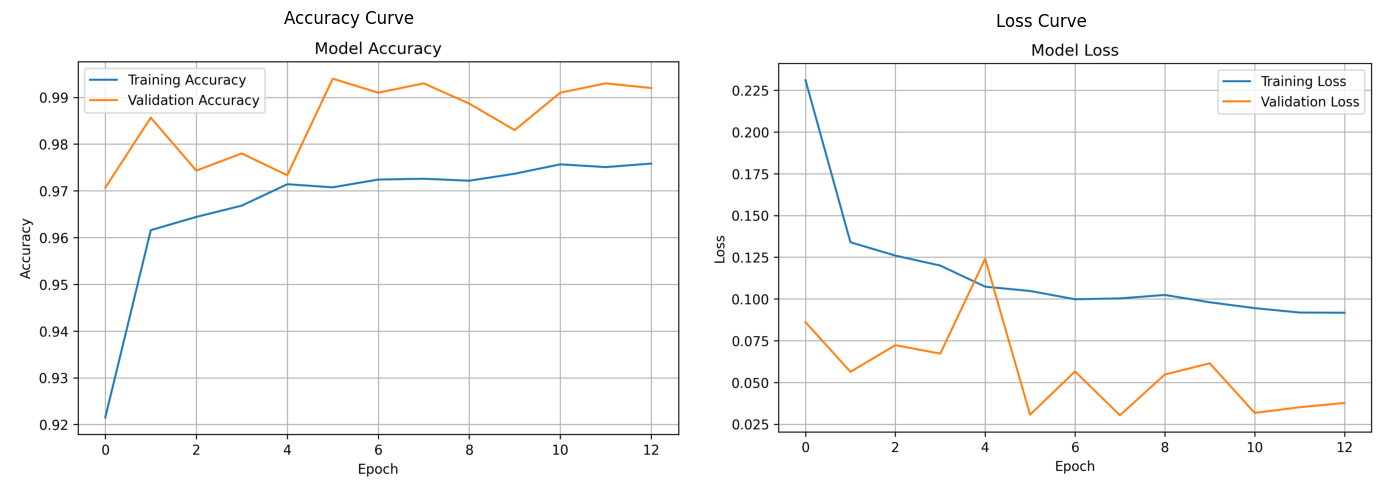

In [10]:
accuracy_path = figures_path / "accuracy_curve.png"
loss_path = figures_path / "loss_curve.png"

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
img = mpimg.imread(accuracy_path)
plt.imshow(img)
plt.title("Accuracy Curve")
plt.axis("off")

plt.subplot(1, 2, 2)
img = mpimg.imread(loss_path)
plt.imshow(img)
plt.title("Loss Curve")
plt.axis("off")

plt.tight_layout()
plt.show()

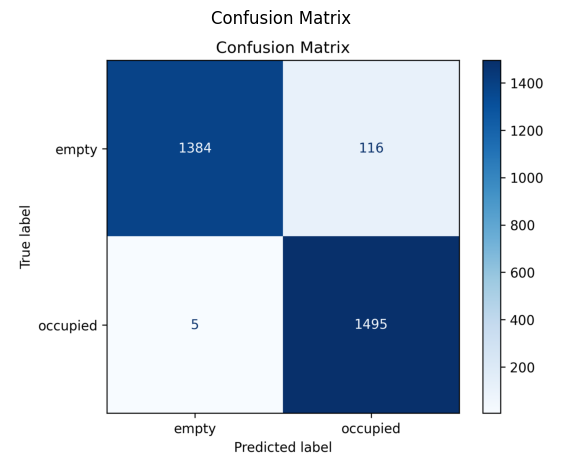

In [11]:
confusion_path = figures_path / "confusion_matrix.png"

img = mpimg.imread(confusion_path)

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.title("Confusion Matrix")
plt.axis("off")
plt.show()

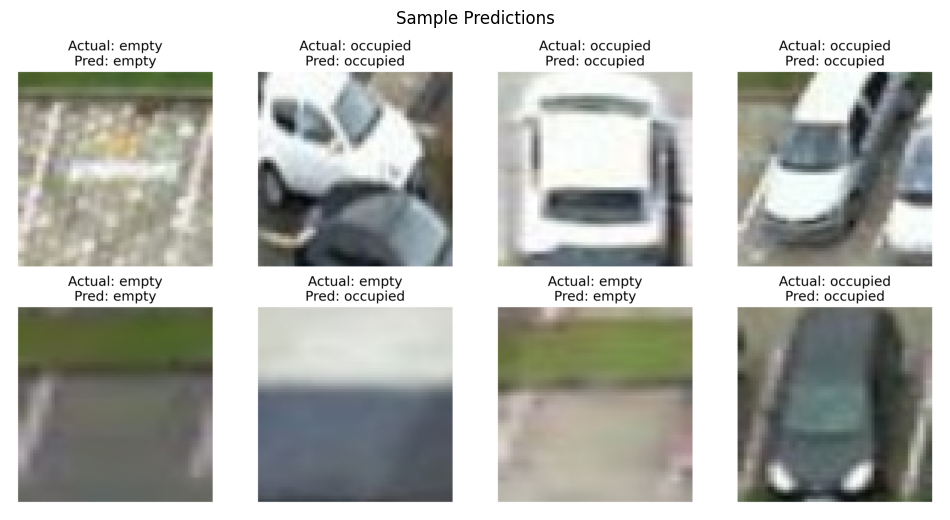

In [12]:
predictions_path = figures_path / "sample_predictions.png"

img = mpimg.imread(predictions_path)

plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.title("Sample Predictions")
plt.axis("off")
plt.show()

In [13]:
summary_text = """
Parking Slot Occupancy Classification - Evaluation Summary

Dataset:
The dataset was converted from COCO object detection format into a classification dataset.
The final dataset contains 18,000 cropped parking slot images:
- Training set: 12,000 images
- Validation set: 3,000 images
- Testing set: 3,000 images

Classes:
- empty
- occupied

Model:
A Convolutional Neural Network (CNN) was trained to classify parking slot images as empty or occupied.
The input images were resized to 64x64 pixels and normalized by scaling pixel values from 0-255 to 0-1.

Final Results:
The trained CNN model achieved a test accuracy of 95.96% and a test loss of 0.1710.

Classification Report:
Both classes achieved an F1-score of 0.96.
The model achieved strong performance in identifying occupied parking spaces, with a recall of 1.00 for the occupied class.

Confusion Matrix:
- 1384 empty spaces were correctly classified as empty.
- 116 empty spaces were misclassified as occupied.
- 1495 occupied spaces were correctly classified as occupied.
- 5 occupied spaces were misclassified as empty.

Analysis:
The model performed very well overall. Most occupied parking spaces were correctly detected, which is important for a parking occupancy system.
However, some empty spaces were misclassified as occupied. This may be caused by shadows, low image resolution, unclear parking boundaries, or parts of nearby vehicles appearing in the cropped image.

Conclusion:
The results show that CNN-based image classification is effective for parking slot occupancy detection.
Future improvements may include using a larger image size, applying more preprocessing techniques, testing transfer learning models, and improving the quality of cropped parking slot images.
"""

summary_path = results_path / "evaluation_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Evaluation summary saved at:")
print(summary_path)

Evaluation summary saved at:
C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\evaluation_summary.txt


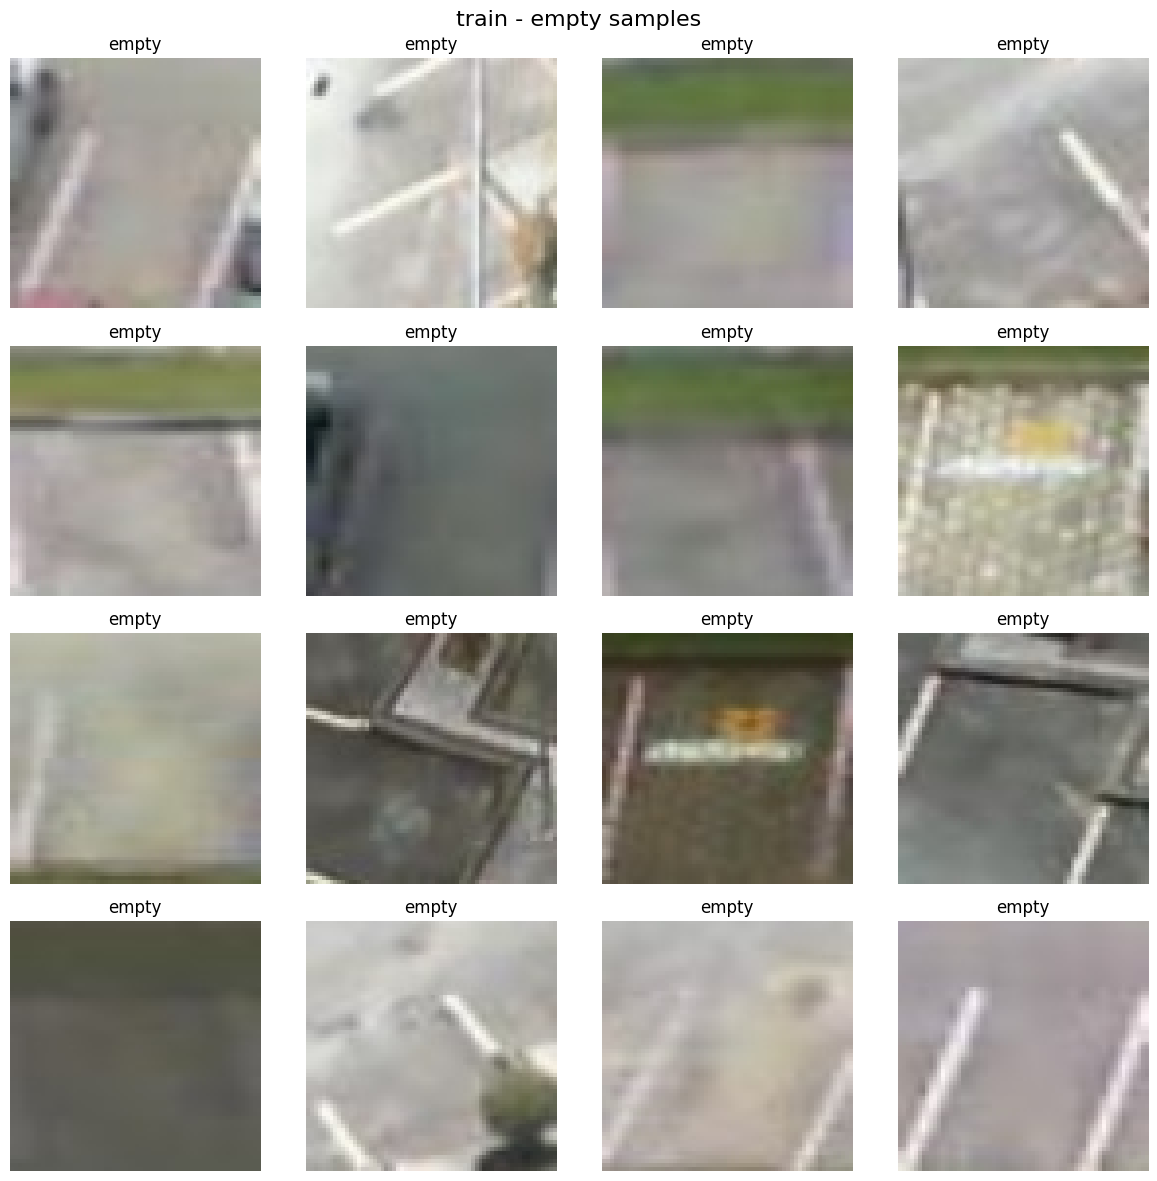

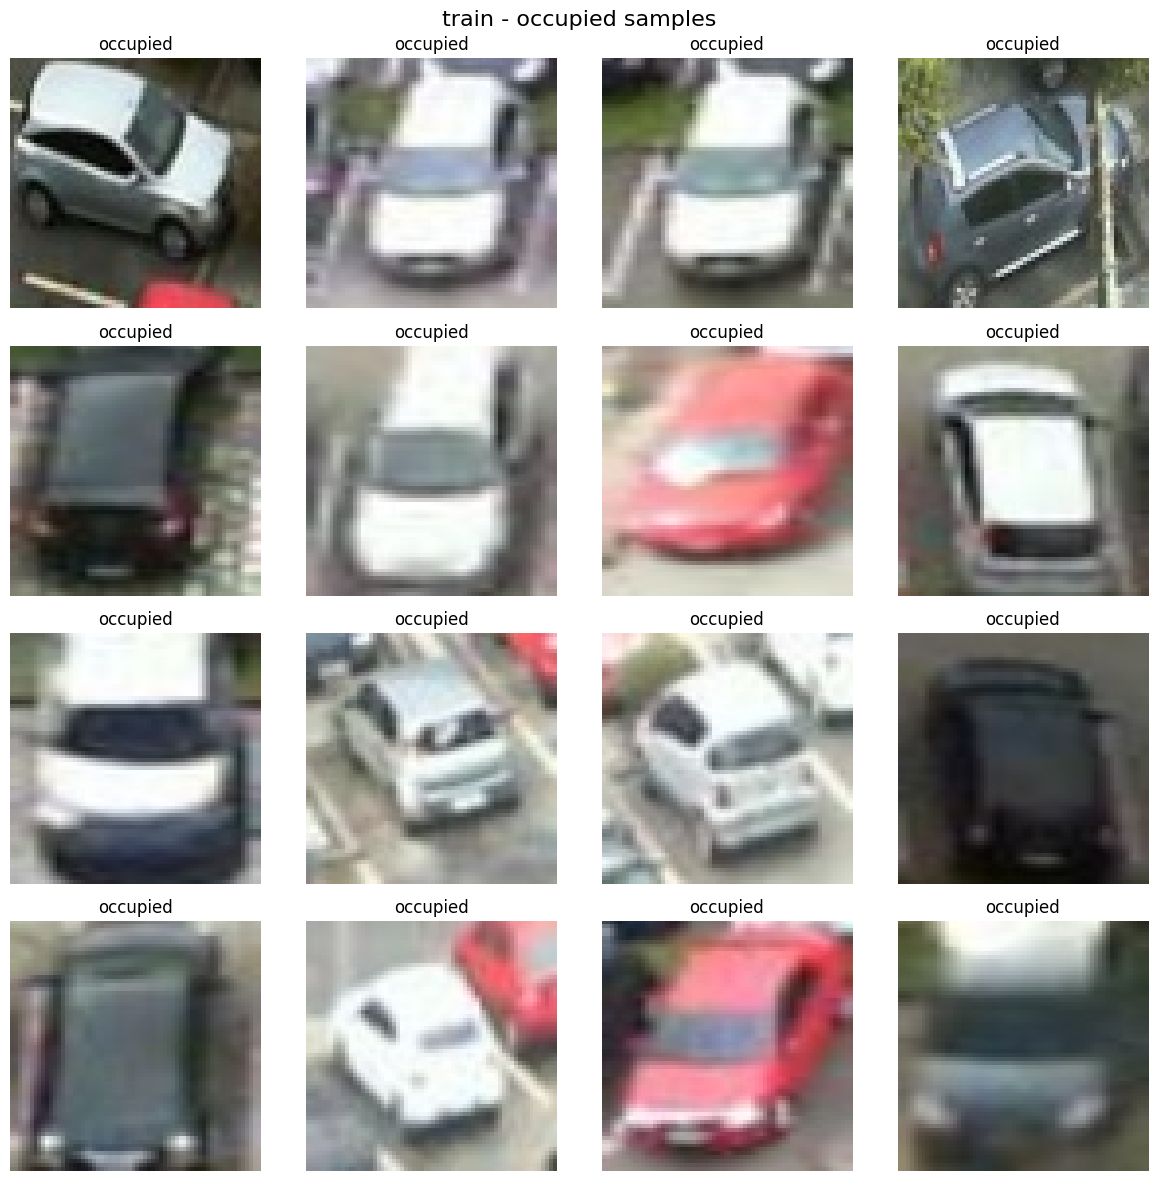

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import random

dataset_path = Path.cwd().parent / "dataset"

def show_more_samples(split="train", class_name="empty", n=16):
    folder = dataset_path / split / class_name
    image_paths = list(folder.glob("*.jpg"))
    
    samples = random.sample(image_paths, min(n, len(image_paths)))
    
    cols = 4
    rows = (len(samples) + cols - 1) // cols
    
    plt.figure(figsize=(12, rows * 3))
    
    for i, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    
    plt.suptitle(f"{split} - {class_name} samples", fontsize=16)
    plt.tight_layout()
    plt.show()

show_more_samples("train", "empty", 16)
show_more_samples("train", "occupied", 16)

In [4]:
import tensorflow as tf
from pathlib import Path

project_path = Path.cwd().parent
models_path = project_path / "results" / "models"

best_model_path = models_path / "best_parking_cnn_model.keras"

model = tf.keras.models.load_model(best_model_path)

print("Model loaded successfully!")
print("Model path:", best_model_path)

ModuleNotFoundError: No module named 'tensorflow'

In [5]:
from pathlib import Path

project_path = Path.cwd().parent
models_path = project_path / "results" / "models"

print("Models folder:", models_path)
print("Files:")

for file in models_path.iterdir():
    print(file.name)

Models folder: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\models
Files:
best_parking_cnn_model.keras
final_parking_cnn_model.keras
